# Task 4
# Movie Recommendation System using Collaborative Filtering

Name: Kalaiarashi S B

 This project demonstartes a movie recommendation system using collaborative filtering techniques.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Datasets

In [2]:
movies=pd.read_csv("movies.csv")
ratings=pd.read_csv("ratings.csv")

## Display Dataset

In [3]:
print(movies.head())

print(ratings.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510


In [4]:
ratings = ratings.head(5000)

## Merge Datasets

In [5]:
df=pd.merge(ratings,movies,on="movieId")
print(df.head())

   userId  movieId  rating   timestamp  \
0       1      296     5.0  1147880044   
1       1      306     3.5  1147868817   
2       1      307     5.0  1147868828   
3       1      665     5.0  1147878820   
4       1      899     3.5  1147868510   

                                              title  \
0                               Pulp Fiction (1994)   
1  Three Colors: Red (Trois couleurs: Rouge) (1994)   
2  Three Colors: Blue (Trois couleurs: Bleu) (1993)   
3                                Underground (1995)   
4                        Singin' in the Rain (1952)   

                        genres  
0  Comedy|Crime|Drama|Thriller  
1                        Drama  
2                        Drama  
3             Comedy|Drama|War  
4       Comedy|Musical|Romance  


In [6]:
df.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0


## Create User-Movie Matrix

In [8]:
movie_matrix = df.pivot_table(

    index='userId',

    columns='title',

    values='rating'
)

In [9]:
print(movie_matrix.head())

title   'burbs, The (1989)  (500) Days of Summer (2009)  \
userId                                                    
1                      NaN                          NaN   
2                      NaN                          NaN   
3                      NaN                          NaN   
4                      NaN                          NaN   
5                      NaN                          NaN   

title   ...And Justice for All (1979)  10 (1979)  10 Rillington Place (1971)  \
userId                                                                         
1                                 NaN        NaN                         NaN   
2                                 NaN        NaN                         NaN   
3                                 NaN        NaN                         NaN   
4                                 NaN        NaN                         NaN   
5                                 NaN        NaN                         NaN   

title   10 Things I Hate 

## Filling Missing Values

In [10]:
movie_matrix = movie_matrix.fillna(0)

## Display of Matrix Shape

In [11]:
print(movie_matrix.shape)

(33, 2411)


## Apply Cosine Similarity

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(

    movie_matrix.T
)


## Create Similarity DataFrame

In [13]:
similarity_df = pd.DataFrame(

    similarity,

    index=movie_matrix.columns,

    columns=movie_matrix.columns
)

## Recommendation Function

In [17]:
def recommend_movies(movie_name):



    similar_scores = similarity_df[movie_name]


    similar_scores = similar_scores.sort_values(
        ascending=False
    )


    print(f"\nMovies similar to '{movie_name}':\n")



    for movie in similar_scores.index[1:11]:

        print(movie)

## Test Recommendation System

In [18]:
recommend_movies("Toy Story (1995)")


Movies similar to 'Toy Story (1995)':

Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode VI - Return of the Jedi (1983)
Star Wars: Episode IV - A New Hope (1977)
Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
Star Wars: Episode V - The Empire Strikes Back (1980)
Lion King, The (1994)
X-Men (2000)
Spider-Man (2002)
Terminator 2: Judgment Day (1991)
Usual Suspects, The (1995)


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     5000 non-null   int64  
 1   movieId    5000 non-null   int64  
 2   rating     5000 non-null   float64
 3   timestamp  5000 non-null   int64  
 4   title      5000 non-null   object 
 5   genres     5000 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 234.5+ KB
None


## Number of Users

In [20]:
print("Total Movies:",
      df['title'].nunique())

Total Movies: 2411


## Most Rated Movies

In [21]:
top_movies = df['title'].value_counts().head(10)

print(top_movies)

title
Pulp Fiction (1994)                                      20
Star Wars: Episode IV - A New Hope (1977)                20
Shawshank Redemption, The (1994)                         19
Star Wars: Episode V - The Empire Strikes Back (1980)    18
Forrest Gump (1994)                                      18
Silence of the Lambs, The (1991)                         18
Star Wars: Episode VI - Return of the Jedi (1983)        17
Back to the Future (1985)                                16
Terminator 2: Judgment Day (1991)                        15
Schindler's List (1993)                                  14
Name: count, dtype: int64


## Plot of Most Rated Movies

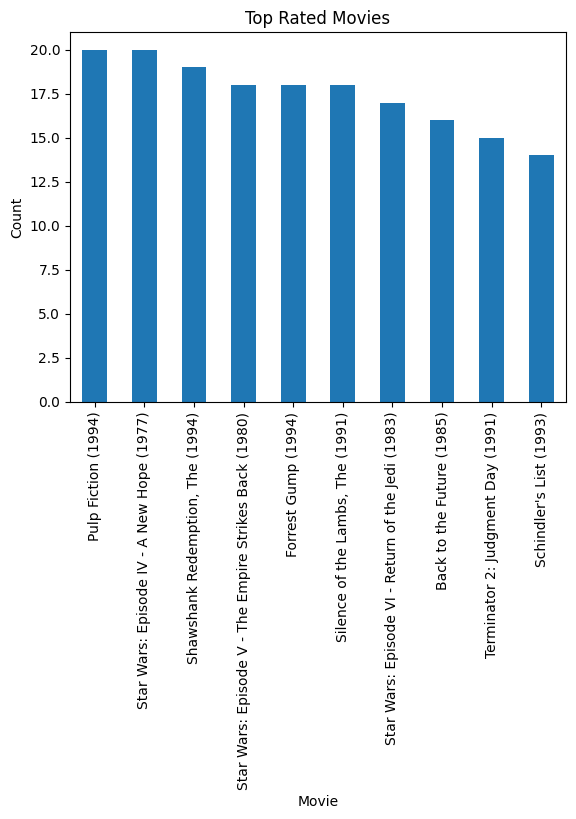

In [22]:
import matplotlib.pyplot as plt

top_movies.plot(
    kind='bar'
)

plt.title("Top Rated Movies")

plt.xlabel("Movie")

plt.ylabel("Count")

plt.show()

## Key insights
1. Collaborative filtering recommends movies based on user rating behavior.

2. Cosine similarity identifies movies with similar user rating patterns.

3. Movies liked by similar users are recommended together.

4. Recommendation systems improve user experience by suggesting relevant content.

5. Collaborative filtering is widely used in platforms like Netflix, Amazon, and Spotify.

6. User-movie interaction data plays a crucial role in recommendation systems.